In [5]:
import pandas as pd
import matplotlib.pyplot as plt

theory = pd.read_csv("../data/dead_end_length_theory.csv")
simulation = pd.read_csv("../data/dead_end_length_simulation.csv")

In [6]:
stats = simulation.groupby("dead_end_length")["absorption_time"].agg(
    simulation_mean="mean",
    simulation_variance="var"
).reset_index()

In [7]:
theory = theory.rename(columns={
    "mean_absorption_time": "theory_mean",
    "variance": "theory_variance"
})

results = theory.merge(stats, on="dead_end_length")

results

,number_of_dead_ends,dead_end_length,initial_state,theory_mean,theory_variance,prob_cheese,prob_cat,simulation_mean,simulation_variance
0,2,1,7,49.0,1568.000000,0.5,0.5,48.3318,1563.335842
1,2,2,7,54.0,1890.428571,0.5,0.5,54.1052,1919.744107
2,2,3,7,59.0,2349.714286,0.5,0.5,59.3008,2291.640283
3,2,4,7,64.0,2985.857143,0.5,0.5,63.8312,3026.551762
4,2,5,7,69.0,3838.857143,0.5,0.5,68.9176,3843.809591
5,2,6,7,74.0,4948.714286,0.5,0.5,73.7432,5017.866240
6,2,7,7,79.0,6355.428571,0.5,0.5,78.8250,6373.888764
7,2,8,7,84.0,8099.000000,0.5,0.5,83.3018,7985.558273
8,2,9,7,89.0,10219.428571,0.5,0.5,90.5810,10168.514490
9,2,10,7,94.0,12756.714286,0.5,0.5,94.8110,12552.325512


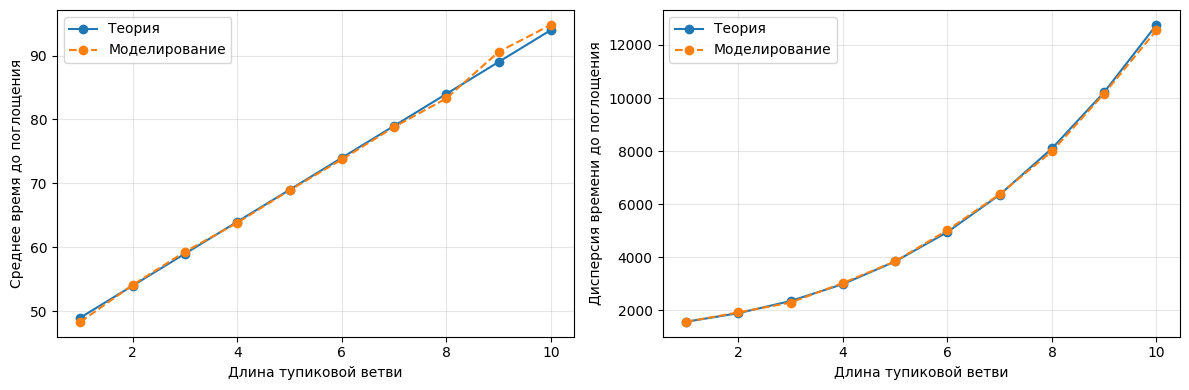

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    results["dead_end_length"],
    results["theory_mean"],
    "o-",
    label="Теория"
)

axes[0].plot(
    results["dead_end_length"],
    results["simulation_mean"],
    "o--",
    label="Моделирование"
)

axes[0].set_xlabel("Длина тупиковой ветви")
axes[0].set_ylabel("Среднее время до поглощения")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    results["dead_end_length"],
    results["theory_variance"],
    "o-",
    label="Теория"
)

axes[1].plot(
    results["dead_end_length"],
    results["simulation_variance"],
    "o--",
    label="Моделирование"
)

axes[1].set_xlabel("Длина тупиковой ветви")
axes[1].set_ylabel("Дисперсия времени до поглощения")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../plots/dead_end_length_experiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()